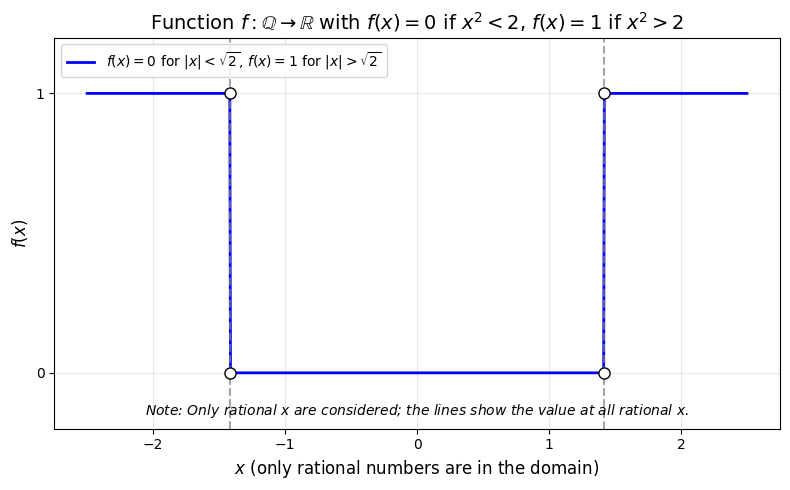

In [2]:
# SageMath code to plot f: Q -> R with f(x)=0 if x^2<2, f(x)=1 if x^2>2

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Option A: Use the default light style
plt.style.use('default')

# Define x range
x = np.linspace(-2.5, 2.5, 1000)
sqrt2 = np.sqrt(2)

# Define the step function (as if defined on all reals; actual domain is only rationals)
y = np.where(np.abs(x) < sqrt2, 0, 1)

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(x, y, 'b-', linewidth=2, label=r'$f(x)=0$ for $|x|<\sqrt{2}$, $f(x)=1$ for $|x|>\sqrt{2}$')

# Vertical dashed lines at the irrational boundaries
plt.axvline(x=-sqrt2, color='gray', linestyle='--', alpha=0.7)
plt.axvline(x=sqrt2, color='gray', linestyle='--', alpha=0.7)

# Open circles to indicate points not in the domain (x = ±√2 are irrational)
plt.plot(-sqrt2, 0, 'wo', markeredgecolor='black', markersize=8)
plt.plot(-sqrt2, 1, 'wo', markeredgecolor='black', markersize=8)
plt.plot(sqrt2, 0, 'wo', markeredgecolor='black', markersize=8)
plt.plot(sqrt2, 1, 'wo', markeredgecolor='black', markersize=8)

# Labels, title, grid, legend
plt.xlabel(r'$x$ (only rational numbers are in the domain)', fontsize=12)
plt.ylabel(r'$f(x)$', fontsize=12)
plt.title(r'Function $f:\mathbb{Q}\to\mathbb{R}$ with $f(x)=0$ if $x^2<2$, $f(x)=1$ if $x^2>2$', fontsize=14)
plt.ylim(-0.2, 1.2)
plt.yticks([0, 1])
plt.grid(alpha=0.3)
plt.legend(loc='upper left')

# Explanation note
plt.text(0, -0.15, 'Note: Only rational $x$ are considered; the lines show the value at all rational $x$.',
         ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

In [ ]:


np.pi

3.141592653589793

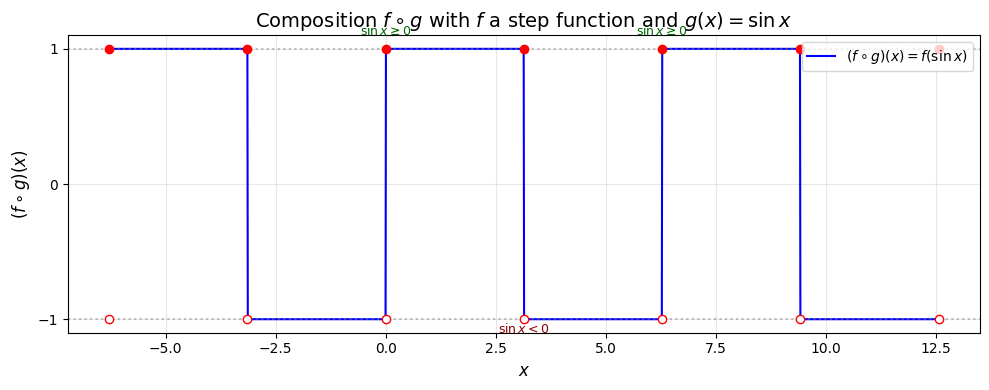

In [ ]:

# SageMath: Plot f∘g with f(x) = -1 (x<0), 1 (x≥0) and g(x)=sin x

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.style.use('default')

def composed(x):
    # Returns f(sin(x))
    s = np.sin(x)
    # f(s): -1 if s<0, else 1
    return np.where(s < 0, -1, 1)

# Generate x values
x = np.linspace(-2*np.pi, 4*np.pi, 2000)

# Compute y = (f∘g)(x)
y = composed(x)

# Plot the step function
plt.figure(figsize=(10, 4))
plt.plot(x, y, 'b-', linewidth=1.5, label=r'$(f\circ g)(x) = f(\sin x)$')

# Mark the discontinuity points (x = kπ)
for k in range(-2, 5):
    x0 = k * np.pi
    # Left limit: from sin(x)<0 -> value -1
    plt.plot(x0, -1, 'wo', markeredgecolor='red', markersize=6, zorder=3)
    # Function value at x0: 1 (since sin=0 -> f(0)=1)
    plt.plot(x0, 1, 'ro', markersize=6, zorder=3)  # filled red dot

# Add horizontal lines at y = -1 and y = 1 for reference
plt.axhline(y=-1, color='gray', linestyle=':', alpha=0.5)
plt.axhline(y=1, color='gray', linestyle=':', alpha=0.5)

# Labels, title, grid
plt.xlabel(r'$x$', fontsize=12)
plt.ylabel(r'$(f\circ g)(x)$', fontsize=12)
plt.title(r'Composition $f\circ g$ with $f$ a step function and $g(x)=\sin x$', fontsize=14)
plt.yticks([-1, 0, 1])
plt.grid(alpha=0.3)
plt.legend(loc='upper right')

# Annotate a few points - use \geq instead of \ge
plt.text(0, 1.1, r'$\sin x \geq 0$', ha='center', fontsize=9, color='darkgreen')
plt.text(np.pi, -1.1, r'$\sin x < 0$', ha='center', fontsize=9, color='darkred')
plt.text(2*np.pi, 1.1, r'$\sin x \geq 0$', ha='center', fontsize=9, color='darkgreen')

plt.tight_layout()
plt.show()

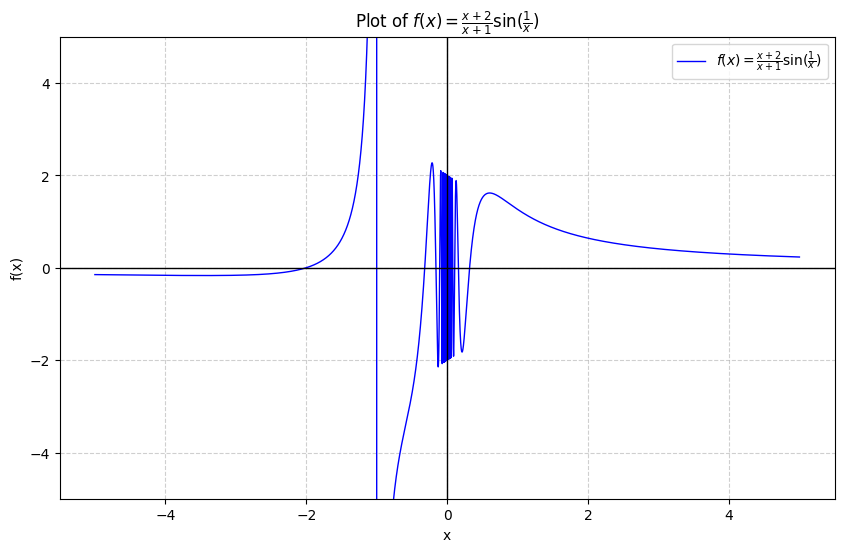

In [4]:
import numpy as np
import matplotlib as mpl

plt.style.use('default')

def f(x):
    # We use numpy operations which work element-wise on arrays
    return ((x + 2) / (x + 1)) * np.sin(1 / x)

# 2. Generate x values
# We create a range from -5 to 5.
# We need a LOT of points (50,000) because sin(1/x) oscillates 
# extremely fast as x gets close to 0.
x = np.linspace(-5, 5, 50000)

# 3. Calculate y values
y = f(x)

# 4. Clean up the data for plotting
# At x = -1, the function goes to infinity. 
# At x = 0, the function is undefined (NaN).
# We replace infinities with NaN so matplotlib doesn't draw 
# vertical lines connecting the asymptotes.
y[np.isinf(y)] = np.nan

# 5. Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x, y, label=r'$f(x) = \frac{x+2}{x+1} \sin(\frac{1}{x})$', color='blue', linewidth=1)

# Add labels and title using LaTeX formatting
plt.title(r'Plot of $f(x) = \frac{x+2}{x+1} \sin(\frac{1}{x})$')
plt.xlabel('x')
plt.ylabel('f(x)')

# Add grid and axes lines
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=1) # X-axis line
plt.axvline(0, color='black', linewidth=1) # Y-axis line

# Limit the Y-axis view. 
# Without this, the vertical asymptote at x=-1 would stretch 
# the graph so much you wouldn't see the oscillations near x=0.
plt.ylim(-5, 5)

plt.legend()
plt.show()